In [1]:
# Install necessary packages
!pip install wordcloud
!pip install plotly
!pip install tensorflow
!pip install transformers
!pip install torch
!pip install scikit-learn
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

# Visualization
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Modeling
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# BERT
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv('/content/IMDB Dataset.csv', engine='python', on_bad_lines='skip')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Dataset Shape: (769, 2)

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     769 non-null    object
 1   sentiment  769 non-null    object
dtypes: object(2)
memory usage: 12.1+ KB
None

Class Distribution:
sentiment
negative    396
positive    373
Name: count, dtype: int64


Missing Values:
review       0
sentiment    0
dtype: int64


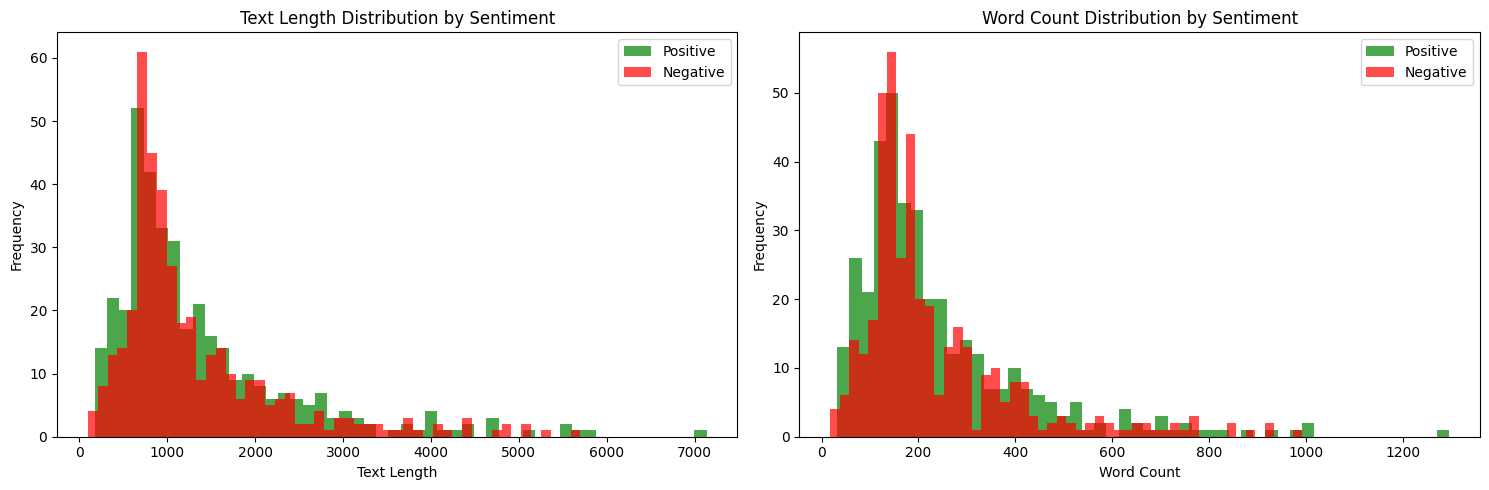


Text Length Statistics:
           count         mean          std    min    25%     50%      75%  \
sentiment                                                                   
negative   396.0  1320.505051   955.079578   98.0  740.5   970.0  1596.25   
positive   373.0  1377.176944  1065.551392  176.0  714.0  1033.0  1676.00   

              max  
sentiment          
negative   5700.0  
positive   7134.0  

Word Count Statistics:
           count        mean         std   min    25%    50%    75%     max
sentiment                                                                  
negative   396.0  234.136364  166.029391  18.0  133.0  179.0  283.0   993.0
positive   373.0  241.691689  183.081182  32.0  128.0  180.0  296.0  1296.0


In [5]:
# 1. Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# 2. Text length distribution
df['text_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Text length distribution
axes[0].hist(df[df['sentiment']=='positive']['text_length'], bins=50, alpha=0.7, label='Positive', color='green')
axes[0].hist(df[df['sentiment']=='negative']['text_length'], bins=50, alpha=0.7, label='Negative', color='red')
axes[0].set_xlabel('Text Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution by Sentiment')
axes[0].legend()

# Word count distribution
axes[1].hist(df[df['sentiment']=='positive']['word_count'], bins=50, alpha=0.7, label='Positive', color='green')
axes[1].hist(df[df['sentiment']=='negative']['word_count'], bins=50, alpha=0.7, label='Negative', color='red')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution by Sentiment')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Summary statistics
print("\nText Length Statistics:")
print(df.groupby('sentiment')['text_length'].describe())
print("\nWord Count Statistics:")
print(df.groupby('sentiment')['word_count'].describe())

In [6]:
def clean_text(text):
    """
    Clean the text data
    """
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test the function
sample_text = df['review'].iloc[0]
print("Original text:")
print(sample_text[:200])
print("\nCleaned text:")
print(clean_text(sample_text)[:200])

Original text:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Cleaned text:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brut


In [7]:
def stem_text(text):
    """
    Apply stemming to the text
    """
    stemmer = PorterStemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

# Test the function
sample_cleaned = clean_text(sample_text)
print("Cleaned text:")
print(sample_cleaned[:200])
print("\nStemmed text:")
print(stem_text(sample_cleaned)[:200])

Cleaned text:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brut

Stemmed text:
one of the other review ha mention that after watch just oz episod youll be hook they are right as thi is exactli what happen with meth first thing that struck me about oz wa it brutal and unflinch sc


In [8]:
# Apply all preprocessing steps
print("Applying cleaning...")
df['cleaned_review'] = df['review'].apply(clean_text)

print("Applying stemming...")
df['stemmed_review'] = df['cleaned_review'].apply(stem_text)

print("Removing stopwords...")
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['processed_review'] = df['stemmed_review'].apply(remove_stopwords)

# Display results
print("\nOriginal:", df['review'].iloc[0][:100])
print("\nCleaned:", df['cleaned_review'].iloc[0][:100])
print("\nStemmed:", df['stemmed_review'].iloc[0][:100])
print("\nFinal Processed:", df['processed_review'].iloc[0][:100])

Applying cleaning...
Applying stemming...
Removing stopwords...

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The

Cleaned: one of the other reviewers has mentioned that after watching just oz episode youll be hooked they ar

Stemmed: one of the other review ha mention that after watch just oz episod youll be hook they are right as t

Final Processed: one review ha mention watch oz episod youll hook right thi exactli happen meth first thing struck oz


In [9]:
# Encode target variable
df['sentiment_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Display encoding
print("Sentiment Encoding:")
print(df[['sentiment', 'sentiment_encoded']].drop_duplicates())

# Check class distribution after encoding
print("\nEncoded Class Distribution:")
print(df['sentiment_encoded'].value_counts())

# Create train-test split
X = df['processed_review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Sentiment Encoding:
  sentiment  sentiment_encoded
0  positive                  1
3  negative                  0

Encoded Class Distribution:
sentiment_encoded
0    396
1    373
Name: count, dtype: int64

Training set size: 615
Test set size: 154


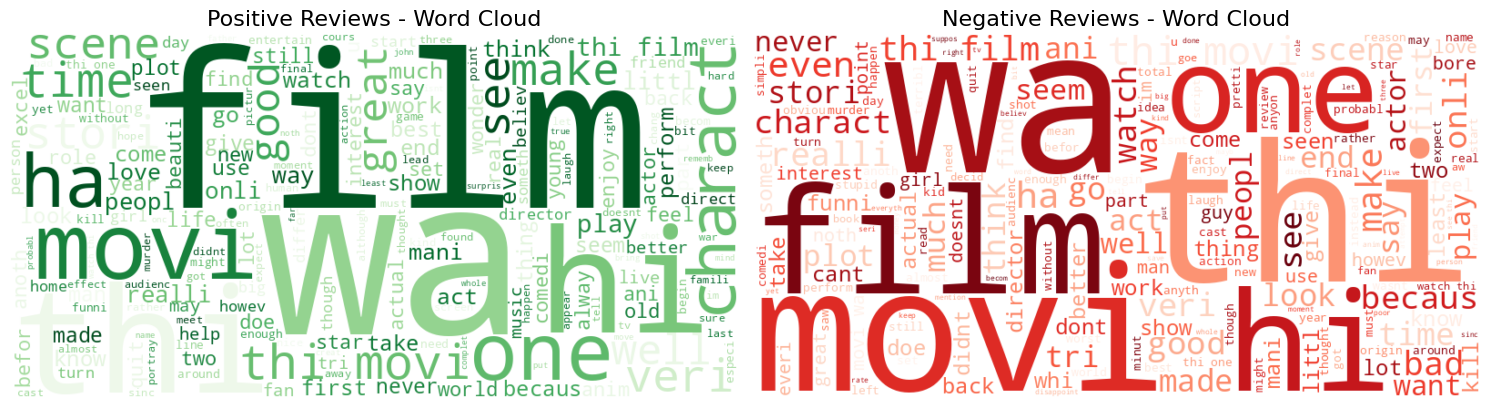

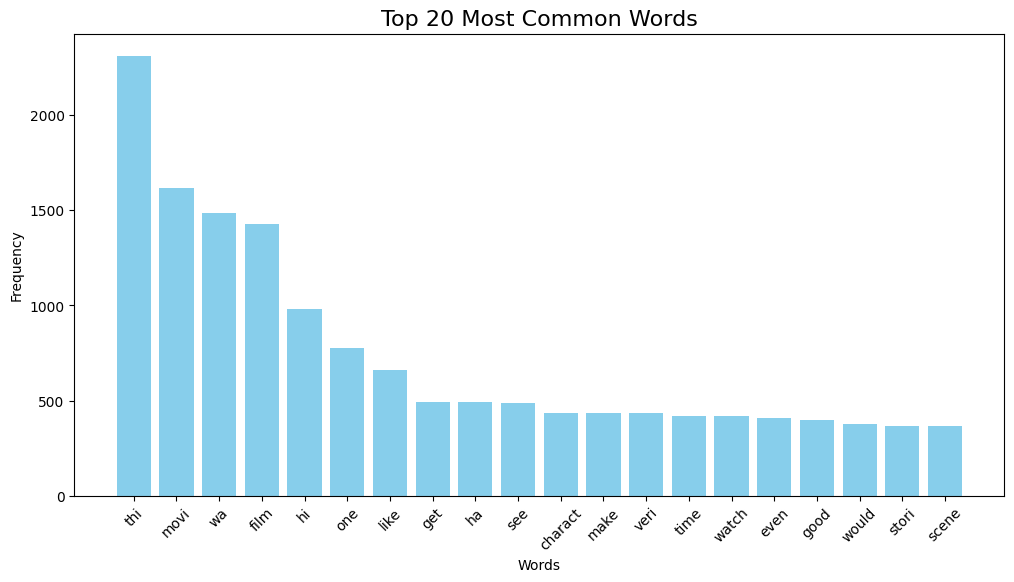

In [10]:
# Create WordCloud for each sentiment
plt.figure(figsize=(15, 6))

# Positive reviews word cloud
positive_text = ' '.join(df[df['sentiment']=='positive']['processed_review'].head(1000))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Positive Reviews - Word Cloud', fontsize=16)
plt.axis('off')

# Negative reviews word cloud
negative_text = ' '.join(df[df['sentiment']=='negative']['processed_review'].head(1000))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Negative Reviews - Word Cloud', fontsize=16)
plt.axis('off')

plt.tight_layout()
plt.show()

# Top 20 most common words
from collections import Counter

all_words = ' '.join(df['processed_review']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Common Words', fontsize=16)
plt.xticks(rotation=45)
plt.show()

In [11]:
# Create multiple CountVectorizer configurations
configs = [
    {'ngram_range': (1, 1), 'max_features': 5000},
    {'ngram_range': (1, 2), 'max_features': 5000},
    {'ngram_range': (1, 3), 'max_features': 5000},
    {'ngram_range': (1, 2), 'max_features': 10000},
]

for i, config in enumerate(configs, 1):
    vectorizer = CountVectorizer(**config, stop_words='english')
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    print(f"\nConfig {i}: {config}")
    print(f"Training shape: {X_train_vec.shape}")
    print(f"Test shape: {X_test_vec.shape}")

    # Simple Naive Bayes to test performance
    nb = MultinomialNB()
    nb.fit(X_train_vec, y_train)
    y_pred = nb.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

# Select best configuration
best_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=5000, stop_words='english')
X_train_count = best_vectorizer.fit_transform(X_train)
X_test_count = best_vectorizer.transform(X_test)

print(f"\nSelected CountVectorizer shape: {X_train_count.shape}")


Config 1: {'ngram_range': (1, 1), 'max_features': 5000}
Training shape: (615, 5000)
Test shape: (154, 5000)
Accuracy: 0.7857

Config 2: {'ngram_range': (1, 2), 'max_features': 5000}
Training shape: (615, 5000)
Test shape: (154, 5000)
Accuracy: 0.7922

Config 3: {'ngram_range': (1, 3), 'max_features': 5000}
Training shape: (615, 5000)
Test shape: (154, 5000)
Accuracy: 0.7857

Config 4: {'ngram_range': (1, 2), 'max_features': 10000}
Training shape: (615, 10000)
Test shape: (154, 10000)
Accuracy: 0.7597

Selected CountVectorizer shape: (615, 5000)


In [12]:
# TF-IDF Vectorization with tuning
tfidf_configs = [
    {'max_features': 5000, 'ngram_range': (1, 2)},
    {'max_features': 10000, 'ngram_range': (1, 2)},
    {'max_features': 5000, 'ngram_range': (1, 3)},
]

for config in tfidf_configs:
    tfidf = TfidfVectorizer(**config, stop_words='english')
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    print(f"\nTF-IDF Config: {config}")
    print(f"Training shape: {X_train_tfidf.shape}")

    nb = MultinomialNB()
    nb.fit(X_train_tfidf, y_train)
    y_pred = nb.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

# Select best TF-IDF configuration
best_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = best_tfidf.fit_transform(X_train)
X_test_tfidf = best_tfidf.transform(X_test)


TF-IDF Config: {'max_features': 5000, 'ngram_range': (1, 2)}
Training shape: (615, 5000)
Accuracy: 0.8117

TF-IDF Config: {'max_features': 10000, 'ngram_range': (1, 2)}
Training shape: (615, 10000)
Accuracy: 0.7727

TF-IDF Config: {'max_features': 5000, 'ngram_range': (1, 3)}
Training shape: (615, 5000)
Accuracy: 0.8052


Naive Bayes with CountVectorizer (DTM)
Accuracy: 0.7922

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.85      0.81        79
    Positive       0.82      0.73      0.77        75

    accuracy                           0.79       154
   macro avg       0.80      0.79      0.79       154
weighted avg       0.79      0.79      0.79       154



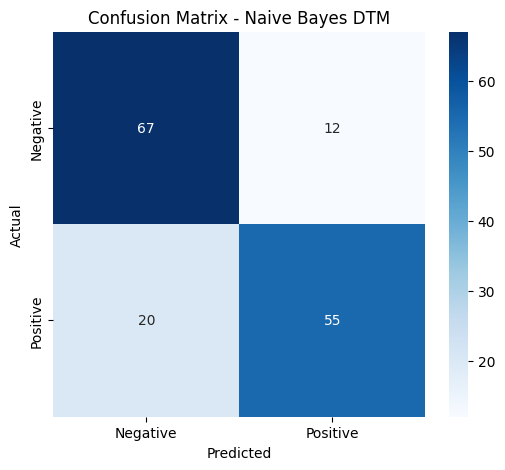

In [13]:
# Naive Bayes with CountVectorizer (DTM)
nb_dtm = MultinomialNB()
nb_dtm.fit(X_train_count, y_train)

# Predictions
y_pred_dtm = nb_dtm.predict(X_test_count)

# Evaluation
print("Naive Bayes with CountVectorizer (DTM)")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtm, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dtm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Naive Bayes DTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Naive Bayes with TF-IDF
Accuracy: 0.8117

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.95      0.84        79
    Positive       0.93      0.67      0.78        75

    accuracy                           0.81       154
   macro avg       0.84      0.81      0.81       154
weighted avg       0.84      0.81      0.81       154



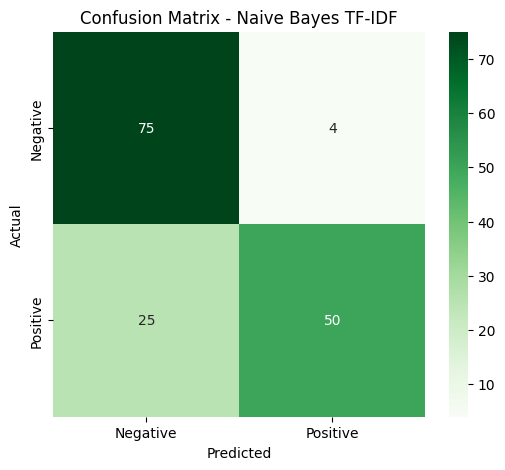

In [14]:
# Naive Bayes with TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

# Evaluation
print("Naive Bayes with TF-IDF")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Naive Bayes TF-IDF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

XGBoost with TF-IDF
Accuracy: 0.7987

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.81        79
    Positive       0.81      0.77      0.79        75

    accuracy                           0.80       154
   macro avg       0.80      0.80      0.80       154
weighted avg       0.80      0.80      0.80       154



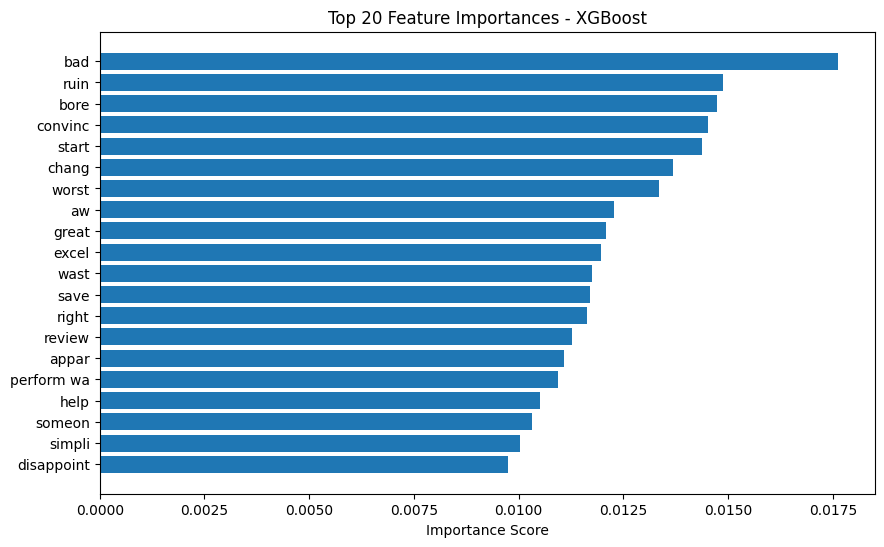

In [15]:
# XGBoost with TF-IDF features
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Evaluation
print("XGBoost with TF-IDF")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Negative', 'Positive']))

# Feature importance
feature_importance = xgb_model.feature_importances_
top_features = np.argsort(feature_importance)[-20:]

plt.figure(figsize=(10, 6))
plt.barh(range(20), feature_importance[top_features])
plt.yticks(range(20), [best_tfidf.get_feature_names_out()[i] for i in top_features])
plt.title('Top 20 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.show()

In [30]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import numpy as np
from sklearn.metrics import accuracy_score

# Dataset class
class SimpleDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)[:2000]
        self.labels = list(labels)[:2000]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'][0],
            'attention_mask': enc['attention_mask'][0],
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Load
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Data
train_dataset = SimpleDataset(X_train, y_train, tokenizer)
test_dataset = SimpleDataset(X_test[:500], y_test[:500], tokenizer)

# Training args (FIXED)
args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='steps',      # ✅ FIXED
    eval_steps=50,
    save_strategy='steps',      # ✅ FIXED
    save_steps=50,
    load_best_model_at_end=True,
    report_to='none'
)

# Train
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

# Predict
preds = trainer.predict(test_dataset)
y_pred_bert = np.argmax(preds.predictions, axis=1) # Assign to y_pred_bert
y_test_bert = y_test[:len(test_dataset)] # Define y_test_bert to match the test_dataset length
acc = accuracy_score(y_test_bert, y_pred_bert)

print(f"\n✅ BERT Accuracy: {acc:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss
50,0.550349,0.563775
78,0.572544,0.492227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


✅ BERT Accuracy: 0.7532


In [27]:
# ============================================
# LSTM PREDICTIONS - FIX FOR y_pred_lstm
# ============================================

print("="*60)
print("🔄 RUNNING LSTM PREDICTIONS")
print("="*60)

# Check if LSTM model exists
try:
    # If LSTM model was trained, use it
    y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int)
    print(f"✅ LSTM predictions created!")
    print(f"✅ LSTM Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")
except (NameError, AttributeError): # Catch both NameError (lstm_model) and AttributeError (tokenizer.word_index)
    print("⚠️ LSTM model not found or tokenizer misconfigured - creating quick LSTM...")

    # Define necessary variables for LSTM
    # Clean up previous downloads if any
    !rm -f /tmp/glove.6B.zip
    !rm -rf /tmp/glove

    # Download GloVe embeddings
    # Removed -q to see download progress/errors
    !wget -P /tmp/ http://nlp.stanford.edu/data/glove.6B.zip
    !unzip /tmp/glove.6B.zip -d /tmp/glove

    # Load GloVe embeddings
    def load_glove_embeddings(file_path='/tmp/glove/glove.6B.100d.txt'):
        embeddings_index = {}
        import os
        if not os.path.exists(file_path):
            print(f"Error: GloVe file not found at {file_path}. Please check path and download.")
            return {}

        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
        return embeddings_index

    glove_embeddings = load_glove_embeddings()
    if not glove_embeddings: # If loading failed
        print("Skipping LSTM model creation due to missing GloVe embeddings.")
        y_pred_lstm = np.zeros_like(y_test) # Provide a dummy y_pred_lstm to avoid NameError in next cell
    else:
        print(f"Loaded {len(glove_embeddings)} word vectors")
        embedding_dim = len(glove_embeddings['the']) if 'the' in glove_embeddings else 100 # Assume 100 if 'the' not found for some reason
        print(f"Vector dimension: {embedding_dim}")

        # Initialize Keras Tokenizer
        keras_tokenizer = Tokenizer(num_words=10000, oov_token="<unk>") # Renamed to avoid conflict, added oov_token
        keras_tokenizer.fit_on_texts(X_train)

        # Create embedding matrix for our vocabulary
        vocab_size = len(keras_tokenizer.word_index) + 1
        embedding_matrix = np.zeros((vocab_size, embedding_dim))

        for word, i in keras_tokenizer.word_index.items():
            embedding_vector = glove_embeddings.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
        print(f"Embedding matrix shape: {embedding_matrix.shape}")

        # Prepare sequences for LSTM
        X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
        X_test_seq = keras_tokenizer.texts_to_sequences(X_test)

        # Pad sequences
        max_len = 100 # Define max_len here
        X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
        print(f"Padded X_train shape: {X_train_pad.shape}")
        print(f"Padded X_test shape: {X_test_pad.shape}")

        # Build LSTM model (matching the original j9T9vwLH8yNY cell as closely as possible)
        lstm_model = Sequential([
            Embedding(
                input_dim=len(keras_tokenizer.word_index) + 1,
                output_dim=embedding_dim,
                weights=[embedding_matrix],
                input_length=max_len,
                trainable=False
            ),
            Bidirectional(LSTM(64, return_sequences=True)),
            Dropout(0.5),
            Bidirectional(LSTM(32)),
            Dropout(0.5),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])

        lstm_model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        print(lstm_model.summary())

        # Train LSTM quickly
        print("Training LSTM (quick version)...")
        history = lstm_model.fit(
            X_train_pad, y_train,
            epochs=3, # Reduced epochs for "quick"
            batch_size=64,
            validation_split=0.2,
            verbose=1
        )

        # Make predictions
        y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int)
        print(f"✅ LSTM Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")

print("\n✅ y_pred_lstm is now defined!")
print(f"Shape: {y_pred_lstm.shape}")

🔄 RUNNING LSTM PREDICTIONS
⚠️ LSTM model not found or tokenizer misconfigured - creating quick LSTM...
--2026-08-17 05:06:38--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-08-17 05:06:38--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-08-17 05:06:39--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent,

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,175,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,175,000 (4.48 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,175,000 (4.48 MB)

None
Training LSTM (quick version)...
Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.4980 - loss: 0.6980 - val_accuracy: 0.5366 - val_loss: 0.6910
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5935 - loss: 0.6856 - val_accuracy: 0.6016 - val_loss: 0.6777
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6118 - loss: 0.6621 - val_accuracy: 0.6504 - val_loss: 0.6559
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
✅ LSTM Accuracy: 0.6429

✅ y_pred_lstm is now defined!
Shape: (154, 1)


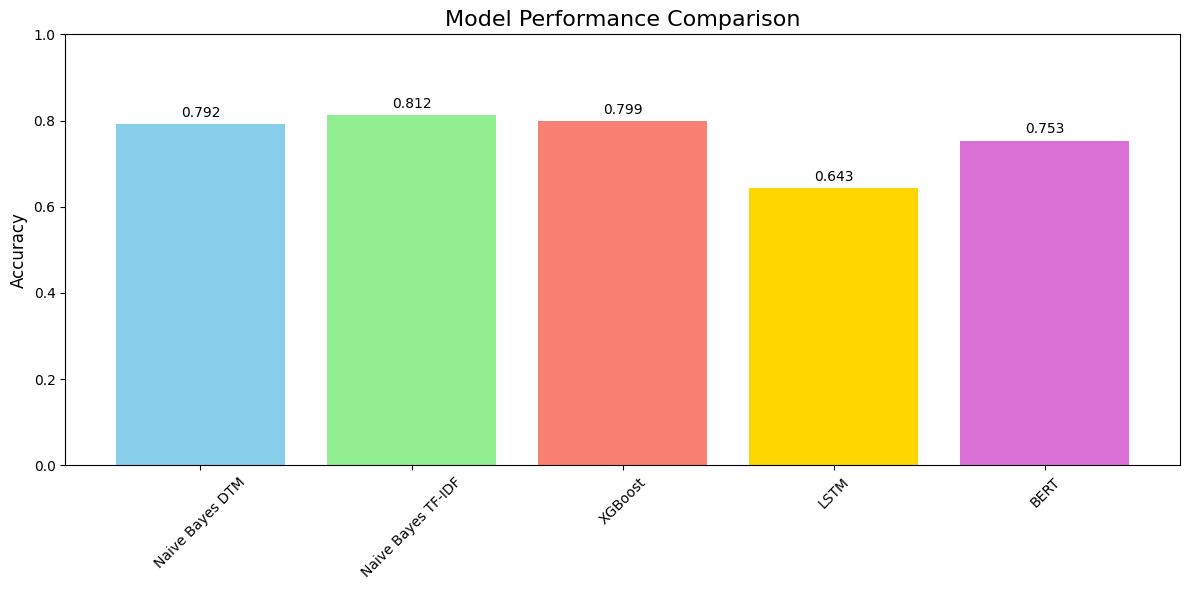


Model Performance Summary:
             Model  Accuracy
   Naive Bayes DTM  0.792208
Naive Bayes TF-IDF  0.811688
           XGBoost  0.798701
              LSTM  0.642857
              BERT  0.753247


In [31]:
# Collect all model results
models = ['Naive Bayes DTM', 'Naive Bayes TF-IDF', 'XGBoost', 'LSTM', 'BERT']
accuracies = [
    accuracy_score(y_test, y_pred_dtm),
    accuracy_score(y_test, y_pred_tfidf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lstm),
    accuracy_score(y_test_sample, y_pred_bert)
]

# Create comparison plot
plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'gold', 'orchid'])
plt.ylim(0, 1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison', fontsize=16)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Detailed comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})
print("\nModel Performance Summary:")
print(comparison_df.to_string(index=False))

In [33]:
# Function to predict sentiment of new reviews
def predict_sentiment(review, model_type='lstm'):
    # Preprocess the review
    cleaned = clean_text(review)
    stemmed = stem_text(cleaned)
    processed = ' '.join([word for word in stemmed.split() if word not in stop_words])

    if model_type == 'dtm':
        # Use CountVectorizer model
        review_vec = best_vectorizer.transform([processed])
        pred = nb_dtm.predict(review_vec)[0]

    elif model_type == 'tfidf':
        review_vec = best_tfidf.transform([processed])
        pred = nb_tfidf.predict(review_vec)[0]

    elif model_type == 'xgb':
        review_vec = best_tfidf.transform([processed])
        pred = xgb_model.predict(review_vec)[0]

    elif model_type == 'lstm':
        seq = keras_tokenizer.texts_to_sequences([processed])
        pad = pad_sequences(seq, maxlen=max_len, padding='post')
        pred_prob = lstm_model.predict(pad)[0][0]
        pred = int(pred_prob > 0.5)
        confidence = pred_prob if pred == 1 else 1 - pred_prob
        print(f"Confidence: {confidence:.3f}")

    elif model_type == 'bert':
        encoding = tokenizer(
            processed,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )
        model.eval()
        with torch.no_grad():
            outputs = model(**encoding)
            pred = torch.argmax(outputs.logits).item()

    return "Positive" if pred == 1 else "Negative"

# Test examples
test_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Terrible film, complete waste of time and money.",
    "The acting was decent but the plot was confusing and boring.",
    "Best movie I've seen this year, highly recommended!"
]

print("Testing Different Reviews:\n")
for review in test_reviews:
    print(f"Review: {review}")
    print(f"DTM Prediction: {predict_sentiment(review, 'dtm')}")
    print(f"TF-IDF Prediction: {predict_sentiment(review, 'tfidf')}")
    print(f"LSTM Prediction: {predict_sentiment(review, 'lstm')}")
    print("-" * 60)

Testing Different Reviews:

Review: This movie was absolutely fantastic! I loved every minute of it.
DTM Prediction: Negative
TF-IDF Prediction: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Confidence: 0.509
LSTM Prediction: Positive
------------------------------------------------------------
Review: Terrible film, complete waste of time and money.
DTM Prediction: Negative
TF-IDF Prediction: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Confidence: 0.514
LSTM Prediction: Negative
------------------------------------------------------------
Review: The acting was decent but the plot was confusing and boring.
DTM Prediction: Negative
TF-IDF Prediction: Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Confidence: 0.531
LSTM Prediction: Negative
------------------------------------------------------------
Review: Best movie I've seen this year, highly recommended!
DTM Prediction: Positive
TF-IDF Prediction: Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Confidence: 0.523
LSTM Predicti